In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

In [3]:
modis = pd.read_csv(r"P:\snowmelt_stochastic_model\data\raw\modis_snow_fraction.csv")

modis['date'] = pd.to_datetime(modis['date'])
modis = modis.sort_values('date')

modis.head()

,system:index,date,snow_fraction,.geo
0,2018_01_01,2018-01-01,1.000000,"{""type"":""MultiPoint"",""coordinates"":[]}"
1,2018_01_02,2018-01-02,0.982063,"{""type"":""MultiPoint"",""coordinates"":[]}"
2,2018_01_03,2018-01-03,0.993243,"{""type"":""MultiPoint"",""coordinates"":[]}"
3,2018_01_04,2018-01-04,0.977147,"{""type"":""MultiPoint"",""coordinates"":[]}"
4,2018_01_05,2018-01-05,1.000000,"{""type"":""MultiPoint"",""coordinates"":[]}"


In [4]:
ds_melt = xr.open_dataset(r"P:\snowmelt_stochastic_model\data\processed\melt_models.nc")

ds_melt

<xarray.Dataset> Size: 80kB
Dimensions:         (time: 1826)
Coordinates:
    number          int64 8B ...
  * time            (time) datetime64[ns] 15kB 2018-01-01 ... 2022-12-31
    expver          (time) <U4 29kB ...
Data variables:
    melt_det        (time) float32 7kB ...
    melt_ar1        (time) float64 15kB ...
    melt_temp_jump  (time) float64 15kB ...

In [5]:
melt_df = ds_melt[['melt_det']].to_dataframe().reset_index()

melt_df.rename(columns={'time': 'date', 'melt_det': 'melt'}, inplace=True)

melt_df['date'] = pd.to_datetime(melt_df['date'])

melt_df.head()

,date,melt,number,expver
0,2018-01-01,0.0,0,0001
1,2018-01-02,0.0,0,0001
2,2018-01-03,0.0,0,0001
3,2018-01-04,0.0,0,0001
4,2018-01-05,0.0,0,0001


In [6]:
df = pd.merge(modis, melt_df, on='date', how='inner')

df.head()

,system:index,date,snow_fraction,.geo,melt,number,expver
0,2018_01_01,2018-01-01,1.000000,"{""type"":""MultiPoint"",""coordinates"":[]}",0.0,0,0001
1,2018_01_02,2018-01-02,0.982063,"{""type"":""MultiPoint"",""coordinates"":[]}",0.0,0,0001
2,2018_01_03,2018-01-03,0.993243,"{""type"":""MultiPoint"",""coordinates"":[]}",0.0,0,0001
3,2018_01_04,2018-01-04,0.977147,"{""type"":""MultiPoint"",""coordinates"":[]}",0.0,0,0001
4,2018_01_05,2018-01-05,1.000000,"{""type"":""MultiPoint"",""coordinates"":[]}",0.0,0,0001


In [9]:
df['snow_smooth'] = df['snow_fraction'].rolling(7, center=True).mean()
df['melt_smooth'] = df['melt'].rolling(7, center=True).mean()
df['melt_norm'] = df['melt_smooth'] / df['melt_smooth'].max()

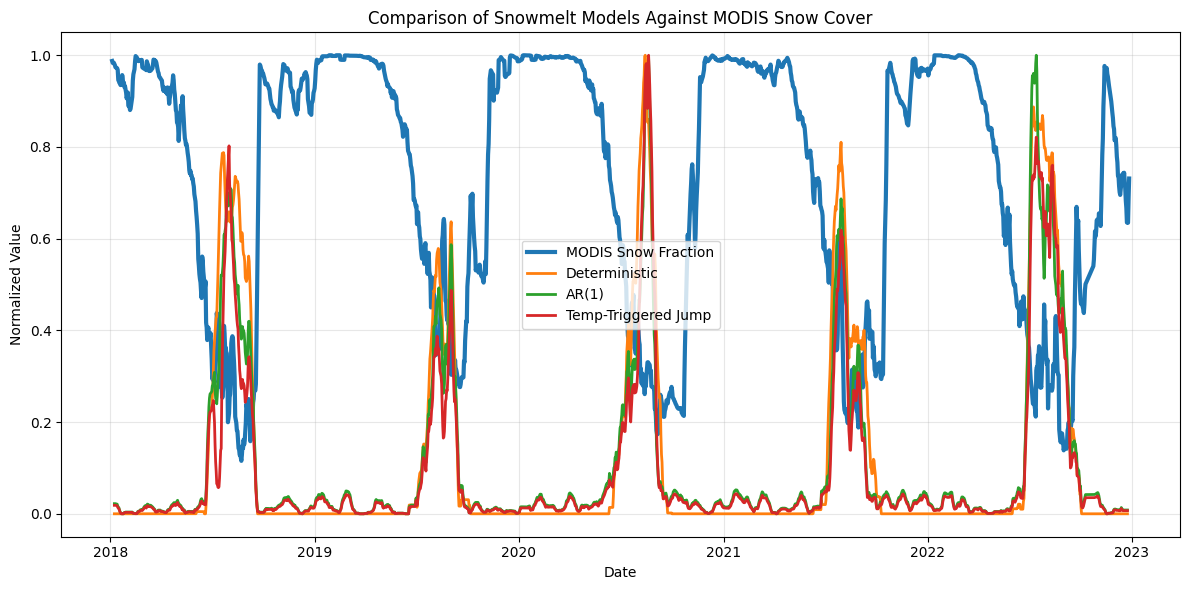

In [12]:
plt.figure(figsize=(12,6))

# Smooth everything
df['melt_det_smooth'] = df['melt'].rolling(14, center=True).mean()

# Load stochastic from dataset again
melt_ar1 = ds_melt['melt_ar1'].to_dataframe().reset_index()
melt_temp = ds_melt['melt_temp_jump'].to_dataframe().reset_index()

# Merge
melt_ar1.rename(columns={'time': 'date'}, inplace=True)
melt_temp.rename(columns={'time': 'date'}, inplace=True)

melt_ar1['date'] = pd.to_datetime(melt_ar1['date'])
melt_temp['date'] = pd.to_datetime(melt_temp['date'])

df = df.merge(melt_ar1[['date','melt_ar1']], on='date', how='left')
df = df.merge(melt_temp[['date','melt_temp_jump']], on='date', how='left')

# Smooth stochastic
df['ar1_smooth'] = df['melt_ar1'].rolling(14, center=True).mean()
df['jump_smooth'] = df['melt_temp_jump'].rolling(14, center=True).mean()

# Normalize all
df['det_norm'] = df['melt_det_smooth'] / df['melt_det_smooth'].max()
df['ar1_norm'] = df['ar1_smooth'] / df['ar1_smooth'].max()
df['jump_norm'] = df['jump_smooth'] / df['jump_smooth'].max()

# Plot
plt.plot(df['date'], df['snow_smooth'], label='MODIS Snow Fraction', linewidth=3)
plt.plot(df['date'], df['det_norm'], label='Deterministic', linewidth=2)
plt.plot(df['date'], df['ar1_norm'], label='AR(1)', linewidth=2)
plt.plot(df['date'], df['jump_norm'], label='Temp-Triggered Jump', linewidth=2)

plt.xlabel("Date")
plt.ylabel("Normalized Value")
plt.title("Comparison of Snowmelt Models Against MODIS Snow Cover")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(r"P:\snowmelt_stochastic_model\outputs\figures\figure_validation_comparison.png", dpi=300)
plt.show()

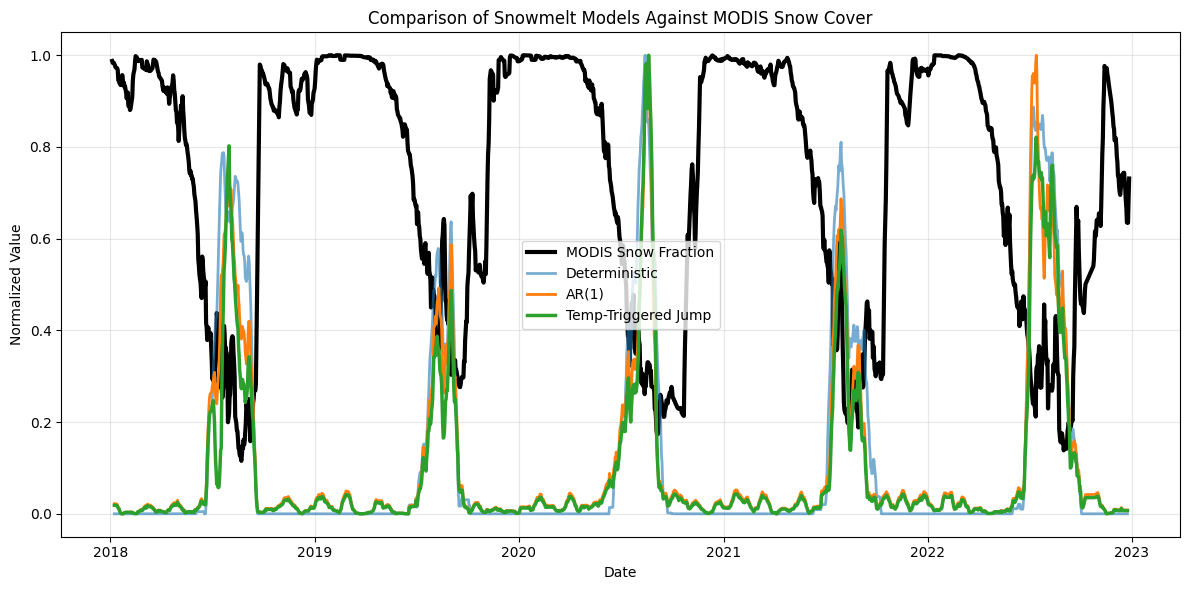

In [13]:
plt.figure(figsize=(12,6))

# MODIS (primary reference)
plt.plot(df['date'], df['snow_smooth'],
         label='MODIS Snow Fraction',
         linewidth=3, color='black')

# Deterministic (baseline, muted)
plt.plot(df['date'], df['det_norm'],
         label='Deterministic',
         linewidth=2, alpha=0.6)

# AR(1)
plt.plot(df['date'], df['ar1_norm'],
         label='AR(1)',
         linewidth=2)

# Jump model (highlight)
plt.plot(df['date'], df['jump_norm'],
         label='Temp-Triggered Jump',
         linewidth=2.5)

plt.xlabel("Date")
plt.ylabel("Normalized Value")
plt.title("Comparison of Snowmelt Models Against MODIS Snow Cover")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(r"P:\snowmelt_stochastic_model\outputs\figures\figure_validation_final.png", dpi=300)
plt.show()

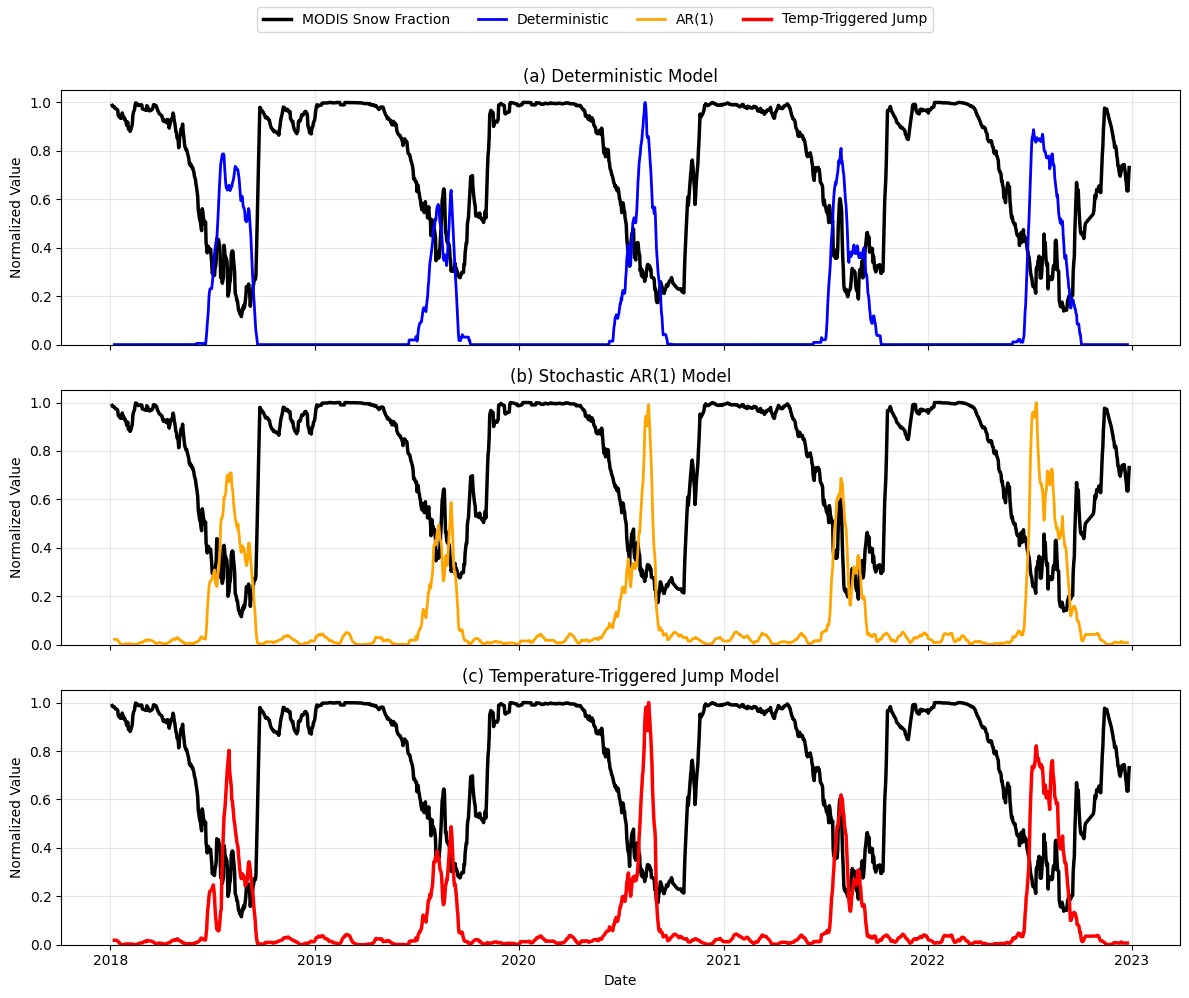

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(12,10), sharex=True)

# -------- Panel 1: Deterministic --------
l1, = axes[0].plot(df['date'], df['snow_smooth'],
                   color='black', linewidth=2.5, label='MODIS Snow Fraction')
l2, = axes[0].plot(df['date'], df['det_norm'],
                   color='blue', linewidth=2, label='Deterministic')

axes[0].set_title('(a) Deterministic Model')
axes[0].grid(alpha=0.3)


# -------- Panel 2: AR(1) --------
l3, = axes[1].plot(df['date'], df['snow_smooth'],
                   color='black', linewidth=2.5, label='MODIS Snow Fraction')
l4, = axes[1].plot(df['date'], df['ar1_norm'],
                   color='orange', linewidth=2, label='AR(1)')

axes[1].set_title('(b) Stochastic AR(1) Model')
axes[1].grid(alpha=0.3)


# -------- Panel 3: Jump --------
l5, = axes[2].plot(df['date'], df['snow_smooth'],
                   color='black', linewidth=2.5, label='MODIS Snow Fraction')
l6, = axes[2].plot(df['date'], df['jump_norm'],
                   color='red', linewidth=2.5, label='Temp-Triggered Jump')

axes[2].set_title('(c) Temperature-Triggered Jump Model')
axes[2].grid(alpha=0.3)


# -------- Axis Labels --------
axes[2].set_xlabel('Date')
for ax in axes:
    ax.set_ylabel('Normalized Value')
    ax.set_ylim(0, 1.05)


# -------- GLOBAL LEGEND --------
fig.legend([l1, l2, l4, l6],
           ['MODIS Snow Fraction', 'Deterministic', 'AR(1)', 'Temp-Triggered Jump'],
           loc='upper center', ncol=4)


# -------- Layout --------
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig(r"P:\snowmelt_stochastic_model\outputs\figures\figure_validation_panels_final.png", dpi=300)
plt.show()

In [18]:
import numpy as np

# Remove NaNs
valid = df.dropna(subset=['snow_smooth', 'det_norm', 'ar1_norm', 'jump_norm'])

# Correlation
corr_det = np.corrcoef(valid['snow_smooth'], valid['det_norm'])[0,1]
corr_ar1 = np.corrcoef(valid['snow_smooth'], valid['ar1_norm'])[0,1]
corr_jump = np.corrcoef(valid['snow_smooth'], valid['jump_norm'])[0,1]

# RMSE (manual)
rmse_det = np.sqrt(np.mean((valid['snow_smooth'] - valid['det_norm'])**2))
rmse_ar1 = np.sqrt(np.mean((valid['snow_smooth'] - valid['ar1_norm'])**2))
rmse_jump = np.sqrt(np.mean((valid['snow_smooth'] - valid['jump_norm'])**2))

print("Correlation:")
print(f"Deterministic: {corr_det:.3f}")
print(f"AR(1): {corr_ar1:.3f}")
print(f"Jump: {corr_jump:.3f}")

print("\nRMSE:")
print(f"Deterministic: {rmse_det:.3f}")
print(f"AR(1): {rmse_ar1:.3f}")
print(f"Jump: {rmse_jump:.3f}")

Correlation:
Deterministic: -0.698
AR(1): -0.662
Jump: -0.633

RMSE:
Deterministic: 0.772
AR(1): 0.755
Jump: 0.757
